<a href="https://colab.research.google.com/github/stella1298/AIFFEL_Quest_EPA/blob/master/NLP/260914_GPT1_Chatbot_haena.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GPT-1 방식의 Decoder-only 언어 모델 구현

## 과제 목표
기존 Transformer Encoder-Decoder 모델을 GPT-1 방식의 Decoder-only Transformer로 변경하고, `ChatbotData.csv`를 이용하여 Next Token Prediction 방식의 언어 모델을 구현한다.

이번 구현에서는 기존 Transformer 코드의
Multi-Head Attention, Feed Forward Network, Residual Connection,
Layer Normalization 등의 구성 요소를 재사용했다.


> 주요 변경 사항:
- Encoder 제거
- Cross-Attention 제거
- Causal Mask 적용
- Token Embedding + 학습 가능한 Position Embedding
- 질문과 답변을 하나의 sequence로 구성
- Next Token Prediction 및 autoregressive generation

## 1. Transformer → GPT-1 구조 변경

기존 Transformer는 Encoder와 Decoder가 분리된 Encoder-Decoder 구조이다.

```text
입력 → Encoder → Memory → Decoder(Self-Attention + Cross-Attention) → 출력
```

GPT-1은 Transformer Decoder 구조를 기반으로 한 Decoder-only 언어 모델이다.

```text
<BOS> 질문 <SEP> 답변 <EOS>
          ↓
Token Embedding + Position Embedding
          ↓
Masked Self-Attention → FFN
          ↓
다음 토큰 예측
```

따라서 기존 Encoder와 Cross-Attention을 제거하고, Causal Mask를 적용한 Self-Attention만 사용한다.

In [1]:
!apt-get -qq install -y fonts-nanum > /dev/null
!pip -q install sentencepiece

from google.colab import drive
drive.mount('/content/drive')

import os, re, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import sentencepiece as spm
from torch.nn.utils.rnn import pad_sequence
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import matplotlib.font_manager as fm
fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fm.fontManager.addfont(fontpath)
plt.rc('font', family=fm.FontProperties(fname=fontpath).get_name())
plt.rc('axes', unicode_minus=False)

print("환경설정 끝")
print("device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("※ GPU를 사용할 수 없습니다. Colab 런타임에서 GPU를 선택하세요.")

Mounted at /content/drive
환경설정 끝
device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


## 2. 데이터 확인

기존 번역 과제의 한국어-영어 병렬 데이터를 사용하지 않고 `ChatbotData.csv`의 Q/A 데이터를 사용한다.

`label`은 분류용 값이므로 이번 언어 모델 사전학습에서는 사용하지 않는다.

In [2]:
CHATBOT_PATH = "/content/drive/MyDrive/Aiffel_EPA/ChatbotData.csv"
if not os.path.exists(CHATBOT_PATH):
    if os.path.exists("/content/ChatbotData.csv"):
        CHATBOT_PATH = "/content/ChatbotData.csv"
    else:
        raise FileNotFoundError(f"파일 경로를 확인하세요: {CHATBOT_PATH}")

df = pd.read_csv(CHATBOT_PATH)
df = df[["Q", "A"]].dropna().drop_duplicates().reset_index(drop=True)

print("데이터 크기:", df.shape)
print(df.head())
print("\n결측치:")
print(df.isnull().sum())

데이터 크기: (11750, 2)
                 Q            A
0           12시 땡!   하루가 또 가네요.
1      1지망 학교 떨어졌어    위로해 드립니다.
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.
4          PPL 심하네   눈살이 찌푸려지죠.

결측치:
Q    0
A    0
dtype: int64


## 3. GPT 입력 데이터 전처리

질문(Q)과 답변(A)의 불필요한 공백을 정리하고, 이후 토큰화에 사용할 수 있도록 텍스트를 전처리한다.

GPT에서는 전처리한 질문과 답변을 각각 토큰화한 후, 특수 토큰을 추가하여 하나의 sequence로 구성한다.

```text
<BOS> 질문 <SEP> 답변 <EOS>
```

`<BOS>`는 시작, `<SEP>`는 질문과 답변의 구분, `<EOS>`는 sequence의 종료를 의미한다.

In [3]:
def clean_text(x):
    return re.sub(r"\s+", " ", str(x).strip())

df["Q"] = df["Q"].map(clean_text)
df["A"] = df["A"].map(clean_text)

print("Q:", df.loc[2, "Q"])
print("A:", df.loc[2, "A"])


Q: 3박4일 놀러가고 싶다
A: 여행은 언제나 좋죠.


## 4. SentencePiece Tokenizer

질문과 답변을 하나의 GPT sequence로 구성하기 위해 하나의 SentencePiece Tokenizer를 사용한다.

질문과 답변은 각각 SentencePiece로 토큰화하고, `<BOS>`, `<SEP>`, `<EOS>`는 미리 정의한 특수 토큰 ID를 직접 추가한다.

특수 토큰 ID는 다음과 같이 구성한다.

```text
PAD=0, BOS=1, EOS=2, UNK=3, SEP=4
```

In [4]:
DATA_DIR = "/content/drive/MyDrive/Aiffel_EPA/gpt1_chatbot"
os.makedirs(DATA_DIR, exist_ok=True)
PREFIX = os.path.join(DATA_DIR, "chatbot_gpt")

MAX_LEN = 64

tokenizer = spm.SentencePieceProcessor()
tokenizer.Load(PREFIX + ".model")

PAD_ID = tokenizer.pad_id()
BOS_ID = tokenizer.bos_id()
EOS_ID = tokenizer.eos_id()
UNK_ID = tokenizer.unk_id()
SEP_ID = tokenizer.piece_to_id("<SEP>")

sequences = []

for q, a in zip(df["Q"], df["A"]):

    # [GPT 변경] 질문과 답변을 각각 토큰화
    q_ids = tokenizer.EncodeAsIds(q)
    a_ids = tokenizer.EncodeAsIds(a)

    # [GPT 변경] 특수 토큰은 문자열이 아니라 ID로 직접 추가
    ids = [BOS_ID] + q_ids + [SEP_ID] + a_ids + [EOS_ID]

    if len(ids) <= MAX_LEN:
        sequences.append(ids)

print("Sequence 개수:", len(sequences))
print("Vocabulary:", tokenizer.GetPieceSize())
print("PAD/BOS/EOS/UNK/SEP:", PAD_ID, BOS_ID, EOS_ID, UNK_ID, SEP_ID)
print("IDs:", sequences[0][:30])

Sequence 개수: 11750
Vocabulary: 8000
PAD/BOS/EOS/UNK/SEP: 0 1 2 3 4
IDs: [1, 4749, 341, 6, 7747, 48, 4, 3424, 85, 107, 14, 5, 2]


In [5]:
VOCAB_SIZE = 8000

with open(PREFIX + ".txt", "w", encoding="utf-8") as f:
    for q, a in zip(df["Q"], df["A"]):
        f.write(q + "\n")
        f.write(a + "\n")

for ext in [".model", ".vocab"]:
    p = PREFIX + ext
    if os.path.exists(p):
        os.remove(p)

spm.SentencePieceTrainer.train(
    input=PREFIX + ".txt",
    model_prefix=PREFIX,
    vocab_size=VOCAB_SIZE,
    pad_id=0,
    bos_id=1,
    eos_id=2,
    unk_id=3,
    user_defined_symbols="<SEP>",
    character_coverage=0.9995
)

tokenizer = spm.SentencePieceProcessor()
tokenizer.Load(PREFIX + ".model")

PAD_ID = tokenizer.pad_id()
BOS_ID = tokenizer.bos_id()
EOS_ID = tokenizer.eos_id()
UNK_ID = tokenizer.unk_id()
SEP_ID = tokenizer.piece_to_id("<SEP>")

In [6]:
sequences = []
MAX_LEN = 64

for q, a in zip(df["Q"], df["A"]):

    # [GPT 변경] 질문과 답변을 각각 토큰화
    q_ids = tokenizer.EncodeAsIds(q)
    a_ids = tokenizer.EncodeAsIds(a)

    # [GPT 변경] 특수 토큰은 ID로 직접 추가
    ids = [BOS_ID] + q_ids + [SEP_ID] + a_ids + [EOS_ID]

    if len(ids) <= MAX_LEN:
        sequences.append(ids)

print("Sequence 개수:", len(sequences))
print("첫 번째 sequence:", sequences[0][:30])

Sequence 개수: 11750
첫 번째 sequence: [1, 4749, 341, 6, 7747, 48, 4, 3424, 85, 107, 14, 5, 2]


In [ ]:
"""
#DATA_DIR = "/content/drive/MyDrive/Aiffel_EPA/gpt1_chatbot"
#os.makedirs(DATA_DIR, exist_ok=True)

VOCAB_SIZE = 8000
#PREFIX = os.path.join(DATA_DIR, "chatbot_gpt")

# Q와 A만 SentencePiece 학습용 텍스트로 사용
with open(PREFIX + ".txt", "w", encoding="utf-8") as f:
    for q, a in zip(df["Q"], df["A"]):
        f.write(q + "\n")
        f.write(a + "\n")

for ext in [".model", ".vocab"]:
    p = PREFIX + ext
    if os.path.exists(p):
        os.remove(p)

spm.SentencePieceTrainer.train(
    input=PREFIX + ".txt",
    model_prefix=PREFIX,
    vocab_size=VOCAB_SIZE,
    pad_id=0,
    bos_id=1,
    eos_id=2,
    unk_id=3,
    user_defined_symbols="<SEP>",
    character_coverage=0.9995
)

tokenizer = spm.SentencePieceProcessor()
tokenizer.Load(PREFIX + ".model")

PAD_ID = tokenizer.pad_id()
BOS_ID = tokenizer.bos_id()
EOS_ID = tokenizer.eos_id()
UNK_ID = tokenizer.unk_id()
SEP_ID = tokenizer.piece_to_id("<SEP>")

print("Vocabulary:", tokenizer.GetPieceSize())
print("PAD/BOS/EOS/UNK/SEP:", PAD_ID, BOS_ID, EOS_ID, UNK_ID, SEP_ID)

q = df["Q"].iloc[0]
a = df["A"].iloc[0]

print("\nQ:", q)
print("Q Tokens:", tokenizer.EncodeAsPieces(q))
print("Q IDs:", tokenizer.EncodeAsIds(q))

print("\nA:", a)
print("A Tokens:", tokenizer.EncodeAsPieces(a))
print("A IDs:", tokenizer.EncodeAsIds(a))
"""

## 5. Input / Target 구성

GPT는 sequence를 한 칸 이동하여 학습한다.

```text
Input  : <BOS> 나는 오늘 학교에
Target : 나는 오늘 학교에 간다
```

각 위치에서 현재까지의 토큰을 이용하여 다음 토큰을 예측한다.

In [8]:
from torch.nn.utils.rnn import pad_sequence

sequence_tensors = [
    torch.tensor(seq, dtype=torch.long)
    for seq in sequences
]

data = pad_sequence(
    sequence_tensors,
    batch_first=True,
    padding_value=PAD_ID
)

print("Sequence:", data.shape)

input_ids = data[:, :-1]
target_ids = data[:, 1:]

print("Input:", input_ids.shape)
print("Target:", target_ids.shape)

Sequence: torch.Size([11750, 41])
Input: torch.Size([11750, 40])
Target: torch.Size([11750, 40])


In [9]:

def show_sequence(ids):
    tokens = []

    for idx in ids:
        if idx == PAD_ID:
            tokens.append("<PAD>")
        elif idx == BOS_ID:
            tokens.append("<BOS>")
        elif idx == EOS_ID:
            tokens.append("<EOS>")
        elif idx == SEP_ID:
            tokens.append("<SEP>")
        else:
            tokens.append(tokenizer.IdToPiece(idx))

    return " ".join(tokens)


print("Vocabulary:", tokenizer.GetPieceSize())
print("PAD/BOS/EOS/UNK/SEP:",
      PAD_ID, BOS_ID, EOS_ID, UNK_ID, SEP_ID)

print("\nSequence:")
print(show_sequence(sequences[0]))

print("\nInput:")
print(show_sequence(input_ids[0].tolist()))

print("\nTarget:")
print(show_sequence(target_ids[0].tolist()))

Vocabulary: 8000
PAD/BOS/EOS/UNK/SEP: 0 1 2 3 4

Sequence:
<BOS> ▁12 시 ▁ 땡 ! <SEP> ▁하루가 ▁또 ▁가 네요 . <EOS>

Input:
<BOS> ▁12 시 ▁ 땡 ! <SEP> ▁하루가 ▁또 ▁가 네요 . <EOS> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>

Target:
▁12 시 ▁ 땡 ! <SEP> ▁하루가 ▁또 ▁가 네요 . <EOS> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>


## 6. GPT Input: Token Embedding + Position Embedding

기존 Transformer에서는 Sinusoidal Positional Encoding을 사용했지만, GPT-1에서는 학습 가능한 Position Embedding을 사용한다.

따라서 입력 표현은 다음과 같이 구성한다.

```text
Token Embedding + Position Embedding
```

In [10]:
# [GPT 변경 ①] Sinusoidal Positional Encoding 대신
# 학습 가능한 Position Embedding 사용

class GPTInput(nn.Module):
    def __init__(self, vocab_size, d_model, max_len):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.position_embedding = nn.Embedding(max_len, d_model)

    def forward(self, input_ids):
        B, L = input_ids.shape
        positions = torch.arange(L, device=input_ids.device).unsqueeze(0)
        return self.token_embedding(input_ids) + self.position_embedding(positions)

## 7. Multi-Head Self-Attention

기존 Transformer의 Multi-Head Attention 기본 연산은 재사용한다. GPT에서는 Q, K, V가 모두 같은 sequence에서 나오므로 Self-Attention을 수행하며 Causal Mask를 적용한다.

In [13]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, q, k, v, mask=None):
        B, Lq, D = q.shape
        Lk = k.size(1)
        q = self.q_proj(q).view(B,Lq,self.n_heads,self.d_k).transpose(1,2)
        k = self.k_proj(k).view(B,Lk,self.n_heads,self.d_k).transpose(1,2)
        v = self.v_proj(v).view(B,Lk,self.n_heads,self.d_k).transpose(1,2)

        score = torch.matmul(q, k.transpose(-2,-1)) / np.sqrt(self.d_k)
        if mask is not None:
            score = score.masked_fill(mask, -1e9)

        attn = F.softmax(score, dim=-1)
        out = torch.matmul(attn, v)
        out = out.transpose(1,2).contiguous()
        B, L, H, D = out.shape
        out = out.view(B,L,H*D)
        return self.out_proj(out), attn

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()

        # [GPT 변경] ReLU → GELU
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.net(x)


In [ ]:
"""
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model,d_ff), nn.ReLU(), nn.Linear(d_ff,d_model)
        )
    def forward(self,x): return self.net(x)
"""

In [12]:
"""
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.net(x)
"""

## 8. GPT Block

기존 Decoder Layer의 Cross-Attention은 Encoder memory가 있을 때 사용하는 구조이다. GPT에는 Encoder가 없으므로 Cross-Attention을 제거한다.

```text
Masked Self-Attention
→ Residual + LayerNorm
→ Feed Forward
→ Residual + LayerNorm
```

In [14]:
# [GPT 변경 ②] 기존 Decoder의 Cross-Attention 제거
# [GPT 변경 ③] Causal Mask를 적용한 Self-Attention 사용

class GPTBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = FeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, causal_mask):
        a, attn = self.self_attn(x, x, x, causal_mask)
        x = self.norm1(x + self.drop(a))
        x = self.norm2(x + self.drop(self.ffn(x)))
        return x, attn

In [15]:
# [GPT 변경 ④] Encoder-Decoder Transformer 대신 Decoder-only 구조

class GPT(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, d_ff,
                 n_layers, dropout, max_len):
        super().__init__()
        self.input = GPTInput(vocab_size, d_model, max_len)
        self.layers = nn.ModuleList([
            GPTBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(d_model, vocab_size)

    def forward(self, input_ids, causal_mask):
        x = self.drop(self.input(input_ids))
        attentions = []
        for layer in self.layers:
            x, attn = layer(x, causal_mask)
            attentions.append(attn)
        return self.fc(x), attentions

## 9. Causal Mask

GPT는 autoregressive language model이므로 미래 토큰을 미리 볼 수 없어야 한다.

`1`인 위치는 Attention을 차단한다.

In [16]:
def generate_causal_mask(size, device):
    return torch.triu(
        torch.ones(size, size, dtype=torch.bool, device=device),
        diagonal=1
    )

print(generate_causal_mask(6, device).int())

tensor([[0, 1, 1, 1, 1, 1],
        [0, 0, 1, 1, 1, 1],
        [0, 0, 0, 1, 1, 1],
        [0, 0, 0, 0, 1, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 0]], device='cuda:0', dtype=torch.int32)


In [17]:
# ============================================================
# 10. 모델 생성 및 차원 확인
# ============================================================

N_LAYERS = 2
D_MODEL = 256
N_HEADS = 8
D_FF = 1024
DROPOUT = 0.1

gpt = GPT(
    tokenizer.GetPieceSize(), D_MODEL, N_HEADS, D_FF,
    N_LAYERS, DROPOUT, MAX_LEN
).to(device)

sample = input_ids[:2].to(device)
mask = generate_causal_mask(sample.size(1), device)

with torch.no_grad():
    output, attentions = gpt(sample, mask)

print("Input:", sample.shape)
print("Output:", output.shape)
print("Attention:", attentions[0].shape)

Input: torch.Size([2, 40])
Output: torch.Size([2, 40, 8000])
Attention: torch.Size([2, 8, 40, 40])


## 11. Next Token Prediction 학습

Input과 Target은 한 칸 이동되어 있다. 모델의 출력 `[B,L,V]`와 Target `[B,L]`을 이용해 Cross Entropy Loss를 계산한다.

PAD 토큰은 Loss 계산에서 제외한다.

In [18]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)
optimizer = optim.AdamW(gpt.parameters(), lr=1e-3)

def train_step(batch_input, batch_target):
    gpt.train()
    batch_input = batch_input.to(device)
    batch_target = batch_target.to(device)

    mask = generate_causal_mask(batch_input.size(1), device)
    optimizer.zero_grad()

    logits, _ = gpt(batch_input, mask)
    loss = criterion(
        logits.reshape(-1, logits.size(-1)),
        batch_target.reshape(-1)
    )

    loss.backward()
    torch.nn.utils.clip_grad_norm_(gpt.parameters(), 1.0)
    optimizer.step()
    return loss.item()

In [21]:
# ============================================================
# 12. GPT 학습
# [GPT 변경 ⑤] 번역이 아닌 Next Token Prediction 수행
# ============================================================

BATCH_SIZE = 64
EPOCHS = 30
indices = np.arange(len(input_ids))
loss_history = []

for epoch in range(1, EPOCHS + 1):
    np.random.shuffle(indices)
    losses = []

    for start in tqdm(
        range(0, len(indices), BATCH_SIZE),
        desc=f"Epoch {epoch}/{EPOCHS}"
    ):
        idx = indices[start:start+BATCH_SIZE]
        losses.append(train_step(input_ids[idx], target_ids[idx]))

    avg_loss = float(np.mean(losses))
    loss_history.append(avg_loss)
    print(f"Epoch {epoch}: Loss = {avg_loss:.4f}")



Epoch 1/30:   0%|          | 0/184 [00:00<?, ?it/s]

Epoch 1: Loss = 1.1960


Epoch 2/30:   0%|          | 0/184 [00:00<?, ?it/s]

Epoch 2: Loss = 1.1758


Epoch 3/30:   0%|          | 0/184 [00:00<?, ?it/s]

...

Epoch 28: Loss = 0.9825


Epoch 29/30:   0%|          | 0/184 [00:00<?, ?it/s]

Epoch 29: Loss = 0.9802


Epoch 30/30:   0%|          | 0/184 [00:00<?, ?it/s]

Epoch 30: Loss = 0.9775


## 13. 학습 Loss 확인

학습이 진행되면서 Loss가 감소하는지 확인한다. Loss가 감소하면 모델이 training sequence의 다음 토큰을 예측하는 패턴을 학습하고 있음을 확인할 수 있다.

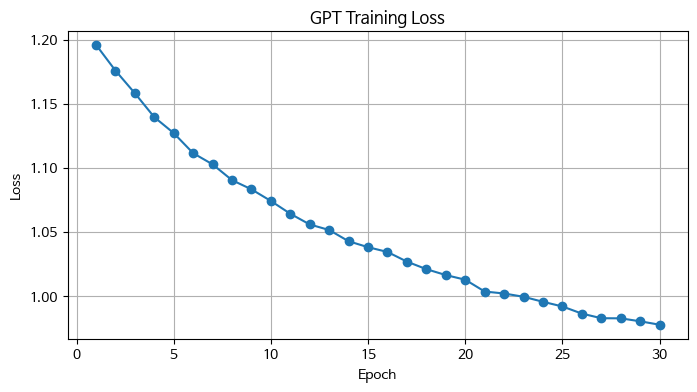

In [22]:
plt.figure(figsize=(8,4))
plt.plot(range(1, len(loss_history)+1), loss_history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GPT Training Loss")
plt.grid()
plt.show()

## 14. GPT 문장 생성

생성 단계에서는 질문과 `<SEP>`까지만 입력한다.

이후 모델이 예측한 토큰을 sequence 뒤에 하나씩 추가하면서 다음 토큰을 반복적으로 생성한다. `<EOS>`가 생성되면 답변 생성을 종료한다.

In [23]:
question = "12시 땡!"

q_ids = tokenizer.EncodeAsIds(clean_text(question))
prompt_ids = [BOS_ID] + q_ids + [SEP_ID]

print("질문:", question)
print("질문 token IDs:", q_ids)
print("모델 입력 IDs:", prompt_ids)
print("SEP_ID:", SEP_ID)

질문: 12시 땡!
질문 token IDs: [4749, 341, 6, 7747, 48]
모델 입력 IDs: [1, 4749, 341, 6, 7747, 48, 4]
SEP_ID: 4


In [24]:
def generate_response(question, max_new_tokens=30, temperature=1.0):
    gpt.eval()

    q_ids = tokenizer.EncodeAsIds(clean_text(question))
    ids = [BOS_ID] + q_ids + [SEP_ID]

    generated = torch.tensor(
        [ids], dtype=torch.long, device=device
    )

    with torch.no_grad():
        for _ in range(max_new_tokens):
            if generated.size(1) >= MAX_LEN:
                break

            mask = generate_causal_mask(
                generated.size(1), device
            )

            logits, _ = gpt(generated, mask)

            next_logits = logits[:, -1, :] / max(
                temperature, 1e-5
            )

            next_logits[:, PAD_ID] = -float("inf")
            next_logits[:, BOS_ID] = -float("inf")

            next_id = torch.argmax(
                next_logits, dim=-1, keepdim=True
            )

            generated = torch.cat(
                [generated, next_id], dim=1
            )

            if next_id.item() == EOS_ID:
                break

    result_ids = generated[0].tolist()

    sep_idx = result_ids.index(SEP_ID)
    answer_ids = result_ids[sep_idx + 1:]

    if EOS_ID in answer_ids:
        answer_ids = answer_ids[:answer_ids.index(EOS_ID)]

    answer_ids = [
        i for i in answer_ids
        if i != PAD_ID
    ]

    return tokenizer.DecodeIds(answer_ids)

In [26]:
"""
def generate_response(question, max_new_tokens=30, temperature=1.0):
    gpt.eval()
    q_ids = tokenizer.EncodeAsIds(clean_text(question))
    ids = [BOS_ID] + q_ids + [SEP_ID]

    generated = torch.tensor([ids], dtype=torch.long, device=device)
    #prompt = BOS + " " + clean_text(question) + " " + SEP
    #ids = tokenizer.EncodeAsIds(prompt)[:MAX_LEN-1]

    #generated = torch.tensor([ids], dtype=torch.long, device=device)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            if generated.size(1) >= MAX_LEN:
                break

            mask = generate_causal_mask(generated.size(1), device)
            logits, _ = gpt(generated, mask)
            next_logits = logits[:, -1, :] / max(temperature, 1e-5)

            next_logits[:, PAD_ID] = -float("inf")
            next_logits[:, BOS_ID] = -float("inf")

            next_id = torch.argmax(next_logits, dim=-1, keepdim=True)
            generated = torch.cat([generated, next_id], dim=1)

            if next_id.item() == EOS_ID:
                break

    result_ids = generated[0].tolist()
    sep_idx = result_ids.index(SEP_ID) if SEP_ID in result_ids else 0
    answer_ids = result_ids[sep_idx+1:]

    if EOS_ID in answer_ids:
        answer_ids = answer_ids[:answer_ids.index(EOS_ID)]

    return tokenizer.DecodeIds(answer_ids)
    """

In [25]:
test_questions = [
    "오늘 너무 힘들어",
    "12시 땡!",
    "주말에 뭐하지?",
    "영화 보고 싶어",
    "기분이 좋지 않아"
]

for q in test_questions:
    print("Q:", q)
    print("A:", generate_response(q))
    print("-" * 50)

Q: 오늘 너무 힘들어
A: 고생 많았어요.
--------------------------------------------------
Q: 12시 땡!
A: 하루가 또 가네요.
--------------------------------------------------
Q: 주말에 뭐하지?
A: 저랑 놀아요.
--------------------------------------------------
Q: 영화 보고 싶어
A: 영화 한 번 크게 지르고 잊어버리세요.
--------------------------------------------------
Q: 기분이 좋지 않아
A: 무슨 이유인지 생각해보세요.
--------------------------------------------------


In [26]:
    print("Q:", "배고프다")
    print("A:", generate_response("배고프다"))

Q: 배고프다
A: 얼른 알아보세요.


In [30]:
print("Q:", df.iloc[0]["Q"])
print("A:", df.iloc[0]["A"])

q_ids = tokenizer.EncodeAsIds(df.iloc[0]["Q"])
a_ids = tokenizer.EncodeAsIds(df.iloc[0]["A"])

ids = [BOS_ID] + q_ids + [SEP_ID] + a_ids + [EOS_ID]

print("IDs:", ids)
print("Decoded:", tokenizer.DecodeIds(ids))

Q: 12시 땡!
A: 하루가 또 가네요.
IDs: [1, 4749, 341, 6, 7747, 48, 4, 3424, 85, 107, 14, 5, 2]
Decoded: 12시 땡!<SEP> 하루가 또 가네요.


In [31]:
print("Q:", "12시 땡!")
print("A:", generate_response("12시 땡!"))

Q: 12시 땡!
A: 하루가 또 가네요.


# 15. 결과 및 고찰

이번 과제에서는 기존 Encoder-Decoder Transformer를 GPT-1 방식의 Decoder-only 구조로 변경하였다.

기존 Transformer에서는 Encoder의 출력인 memory를 Decoder의 Cross-Attention에서 사용했지만, GPT에서는 Encoder와 Cross-Attention을 제거하고 하나의 sequence에 대해 Masked Self-Attention을 수행하도록 변경하였다.

ChatbotData의 질문과 답변은 `<BOS> 질문 <SEP> 답변 <EOS>` 형태로 연결하였다. 이후 sequence를 한 칸 이동하여 Input과 Target을 만들고 Next Token Prediction 방식으로 학습하였다.

또한 기존 Transformer의 Sinusoidal Positional Encoding 대신 학습 가능한 Position Embedding을 사용하였다. Causal Mask를 적용하여 미래 토큰을 참조하지 못하도록 하였으며, 생성 단계에서는 질문과 `<SEP>`까지만 입력하고 예측된 토큰을 반복적으로 추가하여 답변을 생성하였다.

이번 구현의 목적은 실제 GPT-1의 대규모 학습 환경을 그대로 재현하는 것이 아니라, GPT-1의 핵심적인 Decoder-only 구조와 autoregressive language modeling 방식을 기존 Transformer 코드에 적용하고 동작을 확인하는 데 있다.

### 기존 Transformer와의 주요 변경 사항

| 기존 Transformer | GPT 방식 |
|---|---|
| Encoder 사용 | Encoder 제거 |
| Encoder Self-Attention | 제거 |
| Decoder Self-Attention | Masked Self-Attention |
| Cross-Attention | 제거 |
| Encoder memory | 사용하지 않음 |
| Source / Target 분리 | 하나의 sequence |
| Sinusoidal Position Encoding | 학습 가능한 Position Embedding |
| 번역 | Next Token Prediction |
| Causal Mask | 사용 |